In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(seq_length, len(data)):
        x = data[i-seq_length:i]
        y = data[i]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=5, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        # self.fc = nn.Sequential(
        #     nn.Linear(hidden_size, 64),
        #     nn.ReLU(),
        #     nn.Linear(64, output_size)
        # )

    def forward(self, x):
        # Inicializa o estado oculto inicial (h0) com zeros
        # Formato: (num_layers, batch_size, hidden_size)
        # Necessário para iniciar a LSTM — pode ser visto como a "memória" inicial da rede
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Inicializa o estado da célula (c0) com zeros
        # Também com shape (num_layers, batch_size, hidden_size)
        # Esse estado armazena informações de longo prazo dentro da LSTM
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Executa a LSTM sobre a sequência de entrada `x`, utilizando os estados iniciais h0 e c0
        # `out` contém todas as saídas da LSTM para cada passo da sequência (shape: [batch_size, seq_len, hidden_size])
        # O segundo retorno (_) seria a tupla (h_n, c_n) com os estados finais, que não estamos usando aqui
        out, _ = self.lstm(x, (h0, c0))

        # Seleciona apenas a saída da última posição da sequência (out[:, -1, :])
        # Essa saída representa a "memória final" da LSTM após ver toda a sequência
        # Em seguida, passa essa saída pela camada linear final (fc) para gerar a predição
        out = self.fc(out[:, -1, :])  # usa apenas a última saída da sequência
        return out

In [10]:
def train_and_eval_lstm(symbol="MSFT", start="2015-01-01", end="2023-01-01", seq_len=15, epochs=30, batch_size=32):
    # Download da série
    df = yf.download(symbol, start=start, end=end)
    series = df[('Close', symbol)].dropna().values

    # Normalização
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series.reshape(-1,1)).ravel()

    # Transformar para sequência (supervisionado)
    X, y = create_sequences(series_scaled, seq_len)

    # Split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Tensores
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # (batch, seq, 1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    # Modelo
    model = LSTMModel()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Treinamento
    loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_history[-1]:.6f}")

    # Avaliação
    model.eval()
    with torch.no_grad():
        y_pred_t = model(X_test_t.to(device)).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # Inverter escala
    y_pred = scaler.inverse_transform(y_pred_t)
    y_test = scaler.inverse_transform(y_test_np)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"LSTM (PyTorch): RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    # Gráficos
    plt.figure(figsize=(10,5))
    plt.plot(y_test, label='Real')
    plt.plot(y_pred, label='Predito')
    plt.title("Série Real vs Predita (LSTM - PyTorch)")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(loss_history)
    plt.title("Histórico de perda")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot((y_test - y_pred), label="Resíduo")
    plt.title("Erro de predição (resíduo)")
    plt.grid()
    plt.show()

    return model, y_test, y_pred

/tmp/ipython-input-2547395873.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Epoch 1/90 - Loss: 0.049060
Epoch 2/90 - Loss: 0.003038
Epoch 3/90 - Loss: 0.001177
Epoch 4/90 - Loss: 0.000889
Epoch 5/90 - Loss: 0.000590
Epoch 6/90 - Loss: 0.000567
Epoch 7/90 - Loss: 0.000717
Epoch 8/90 - Loss: 0.000561
Epoch 9/90 - Loss: 0.000507
Epoch 10/90 - Loss: 0.000541
Epoch 11/90 - Loss: 0.000543
Epoch 12/90 - Loss: 0.000647
Epoch 13/90 - Loss: 0.000470
Epoch 14/90 - Loss: 0.000438
Epoch 15/90 - Loss: 0.000465
Epoch 16/90 - Loss: 0.000470
Epoch 17/90 - Loss: 0.000426
Epoch 18/90 - Loss: 0.000443
Epoch 19/90 - Loss: 0.000655
Epoch 20/90 - Loss: 0.000483
Epoch 21/90 - Loss: 0.000461
Epoch 22/90 - Loss: 0.000476
Epoch 23/90 - Loss: 0.000425
Epoch 24/90 - Loss: 0.000380
Epoch 25/90 - Loss: 0.000379
Epoch 26/90 - Loss: 0.000358
Epoch 27/90 - Loss: 0.000387
Epoch 28/90 - Loss: 0.000417
Epoch 29/90 - Loss: 0.000379
Epoch 30/90 - Loss: 0.000435
Epoch 31/90 - Loss: 0.000312
Epoch 32/90 - Loss: 0.000304
Epoch 33/90 - Loss: 0.000336
Epoch 34/90 - Loss: 0.000307
Epoch 35/90 - Loss: 0.0

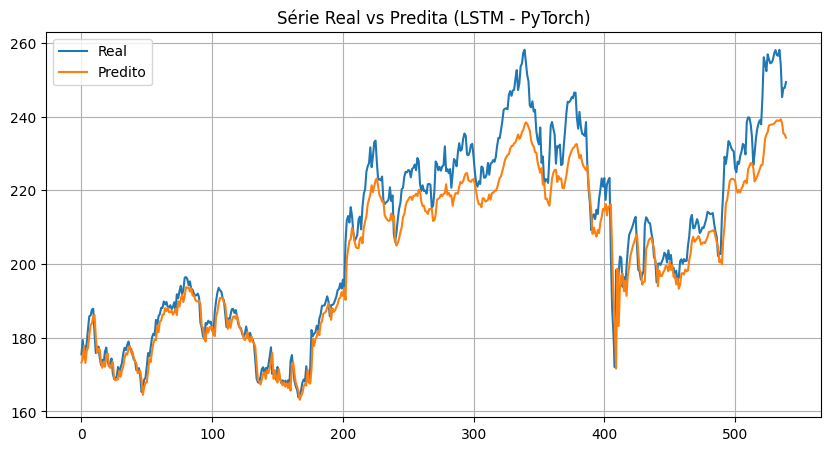

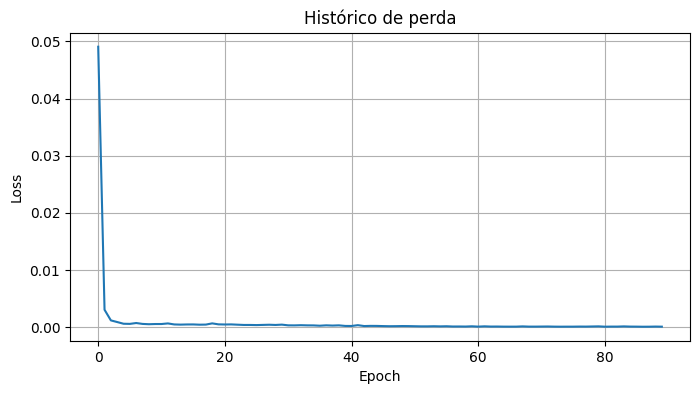

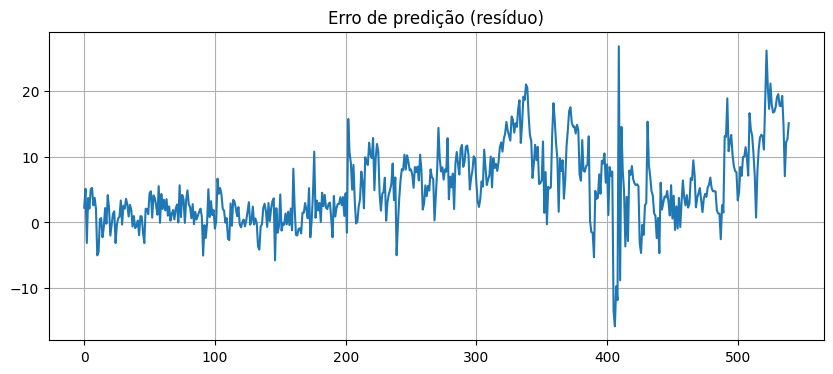

In [11]:
model, y_real, y_pred = train_and_eval_lstm("AAPL", start="2015-01-01", end="2025-10-16", seq_len=15, epochs=90)

# Exercícios

## 1) Alteração da arquitetura

Modifique a arquitetura da LSTM para:
- Adicionar uma segunda camada LSTM
- Incluir uma camada `Dropout(p=0.2)` entre as duas LSTM
- Comparar os resultados com a versão original

> 💡 Lembre-se de atualizar os `hidden_states` e ajustar `num_layers`.

---

## 2) Diferentes tamanhos de janela

Varie o tamanho da janela (`seq_len`) para:
- 10
- 20
- 30

Registre as métricas de erro (RMSE, MAE) e compare os resultados. Qual o impacto de janelas maiores?

---

## 3) Predição multistep

Adapte o modelo LSTM para realizar **previsões de múltiplos passos à frente**, por exemplo:
- Prever os próximos 5 dias de forma sequencial (multi-step forecast)

---

## 4) Variáveis exógenas

Inclua variáveis exógenas na entrada da LSTM. Sugestão:

- `Volume` da ação como segunda feature

> Dica: será necessário transformar a entrada de `(batch, seq_len, 1)` para `(batch, seq_len, 2)`.
